In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [2]:
#a = 1.0 * 10**(-9)
#N = 49
#L = (N+1)*a
#print("L=", L, "m")
#print(" <moduleL=", L/a, "nm") we change a and N to have more precise plots
a = 0.5 * 10**(-9)
a_nm = a * 10 ** 9 #so the lattice looks decent
N = 99
L = (N+1)*a
print("L=", L, "m")
print(" <moduleL=", L/a, "nm")

L= 5.0000000000000004e-08 m
 <moduleL= 100.0 nm


In [3]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]

In [4]:
t = (h_bar**2) / (2*m_el*(a**2))
t = t / eV_unit

print("t=", t)

t= 0.15239927954599816


In [5]:
sys = kwant.Builder()

In [6]:
lat = kwant.lattice.chain(a_nm)

In [7]:
#lets do onsite energies
for i in range(N):
    sys[lat(i)] = 2 * t


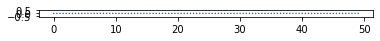

In [8]:
kwant.plot(sys);

In [9]:
#the dots are not yet connected since there are no hoppings
#now we add hoppings
for i in range(N):
    sys[lat(i)] = 2 * t
    
sys[lat.neighbors()] = -t


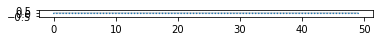

In [10]:
kwant.plot(sys);

In [11]:
#now we extract matrix hamiltonian but not mannualy
#but first we make our system firm, anchangable
sysf = sys.finalized()

In [13]:
Hmat = sysf.hamiltonian_submatrix()

In [14]:
print(Hmat / t)

[[ 2.+0.j -1.+0.j  0.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  2.+0.j -1.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  2.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 ...
 [ 0.+0.j  0.+0.j  0.+0.j ...  2.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j ... -1.+0.j  2.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j ...  0.+0.j -1.+0.j  2.+0.j]]


In [15]:
ene, v = np.linalg.eigh(Hmat)
#ene returns the tabel of eigenvalues E_1, E_2, ... and v returns the matrixv_1, v_2, ... 
#(of vectrors of the wavefunction v_1 corresponds to the E_1 and so on...)

Text(0.5, 1.0, 'Eigen(n)')

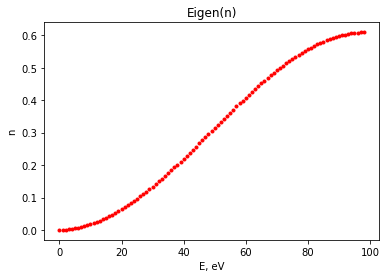

In [16]:
ntab = np.arange(N)
plt.plot(ntab, ene, "r.");

plt.xlabel("E, eV")
plt.ylabel("n")
plt.title("Eigen(n)")

In [23]:
ene_a = np.zeros(N)
ene_a[48]

0.0

In [24]:
#now we want to create a function wich plots for as the given number of columns
from ipywidgets import interact

In [25]:
xtab = np.arange(1, N+1)
print(xtab)
def plot_wf(n):
    print("E =", ene_a[n], "eV")
    plt.plot(xtab, abs(v[:,n]) ** 2);

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
 97 98 99]


In [26]:
interact(plot_wf, n=(0, 20))
#we have to little amount of points

interactive(children=(IntSlider(value=10, description='n', max=20), Output()), _dom_classes=('widget-interact'…

<function __main__.plot_wf(n)>